In [1]:
import os
from os import path
import sys

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1

In [20]:
args = {}

args["project_root"] = path.abspath(path.join(os.path.abspath(""), ".."))
args["web_faces_dir"] = path.join(
    args["project_root"], "dataset", "web_faces")

# args["device"] = torch.device(
#     "cuda:0" if torch.cuda.is_available() else "cpu")
args["device"] = torch.device("cpu")

In [3]:
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets


class ImagePairsDataset(Dataset):
    """
    ImagePairsDataset(imgs_dir)

    Create a dataset of image pairs from the given dataset directory.

    Params:
        - imgs_dir: (path or path-like) Represents the path to the directory of images.
    """

    def __init__(self, imgs_dir, device=torch.device("cpu")):
        data, targets = self._create_pairs_dataset(imgs_dir)

        self._data = torch.tensor(data, device=device)
        self._targets = torch.tensor(targets, device=device)
        self._class_to_idx = {"Same": 0, "Different": 1}
        self._idx_to_class = {i: c for c, i in self._class_to_idx.items()}

    def __len__(self):
        return len(self._targets)

    def __getitem__(self, idx):
        return self._data[idx], self._targets[idx]

    @property
    def class_to_idx(self):
        return self._class_to_idx

    @property
    def idx_to_class(self):
        return self._idx_to_class

    def _create_pairs_dataset(self, imgs_dir):
        # Create a torch dataset of pairs of images along with their labels

        imgs, labels = self._get_labelled_images(imgs_dir)
        labels_set = set(labels)
        rng = np.random.default_rng(seed=42)
        data, targets = [], []

        for l in labels_set:
            same = imgs[labels == l]
            diff = imgs[labels != l]
            
            if len(same) > 1:
                same_idx = rng.integers(
                    low=1,
                    high=len(same), size=1).item()
            else:
                same_idx = rng.integers(len(same), size=1).item()
                
            diff_idx = rng.integers(len(diff), size=1).item()
            data.append([same[0], same[same_idx]])
            data.append([same[0], diff[diff_idx]])
            targets.append(0)  # Same faces
            targets.append(1)  # Different faces

        return np.array(data), np.array(targets)

    def _get_labelled_images(self, imgs_dir, height=600, width=800):
        # Create a torch Dataset using torchvision.datasets.ImageFolder
        image_dataset = datasets.ImageFolder(imgs_dir)

        imgs = np.array(image_dataset.imgs)
        imgs, targets = imgs[:, 0], imgs[:, -1]

        # Convert all image paths to 600x800 images and clip to 3 channels
        data = [np.array(Image.open(img).resize((width, height)))[:, :, :3]
                for img in imgs]

        return np.r_[data], np.array(targets, dtype="uint8")


pairs_loader = DataLoader(
    ImagePairsDataset(args["web_faces_dir"], device=args["device"]),
    batch_size=20,
    shuffle=True)

In [5]:
mtcnn = MTCNN(
    image_size=160,
    margin=0,
    select_largest=True,
    keep_all=False,
    post_process=True,
    device=args["device"])

/home/workerap/.conda/envs/face-rec-fastapi/lib/python3.7/site-packages/ipykernel_launcher.py:21: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
/home/workerap/.conda/envs/face-rec-fastapi/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  del sys.path[0]


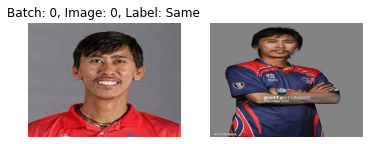

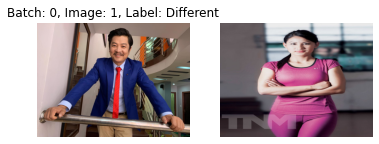

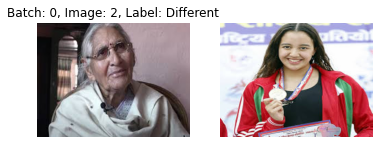

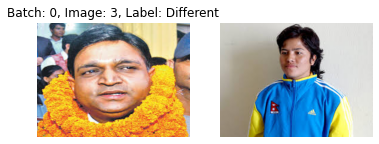

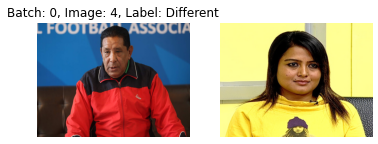

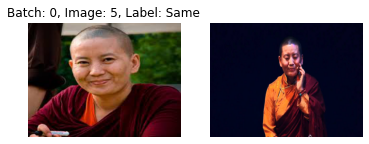

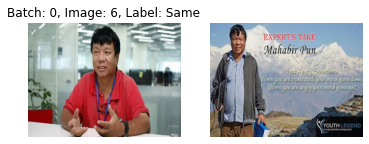

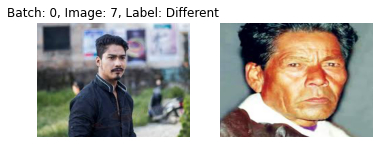

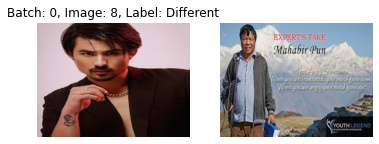

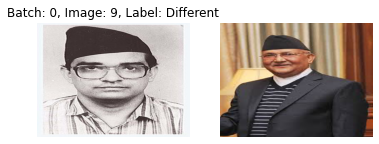

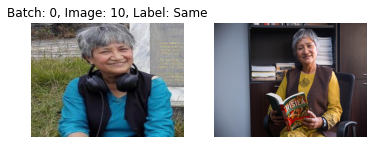

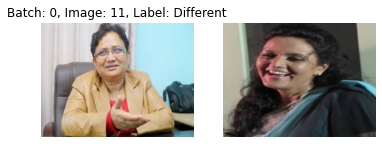

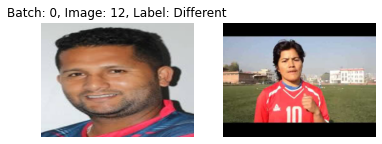

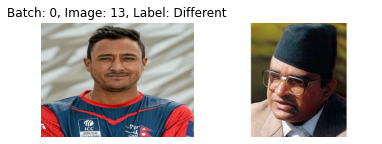

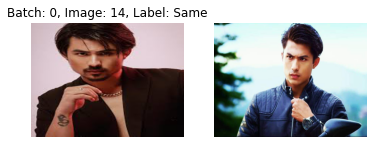

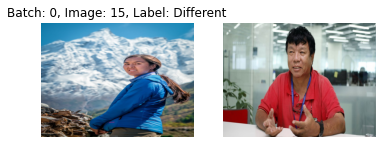

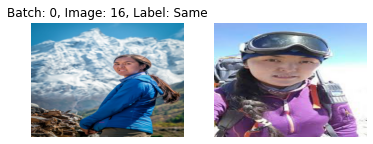

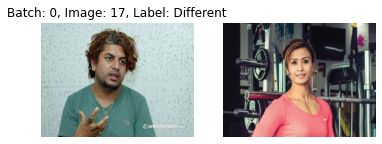

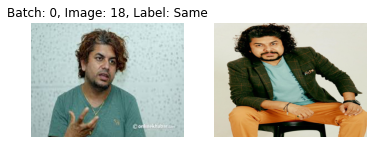

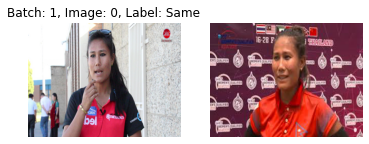

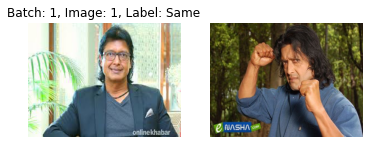

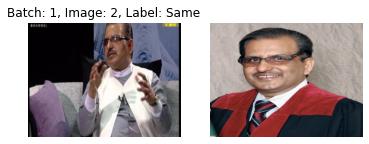

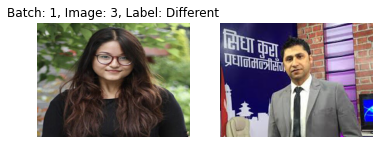

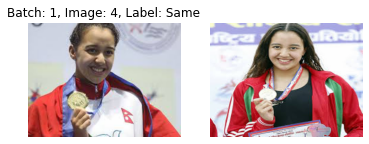

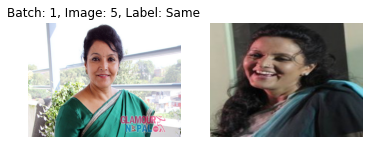

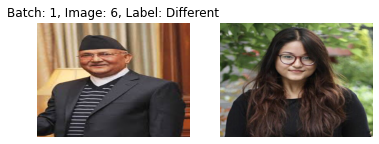

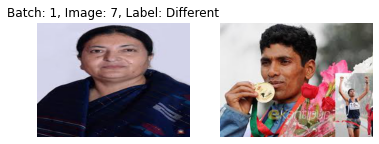

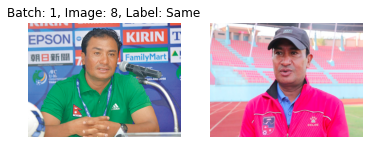

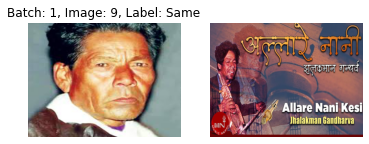

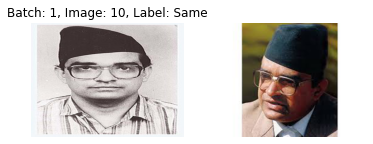

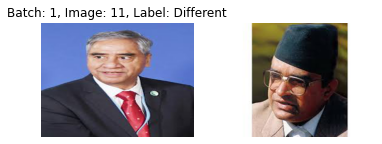

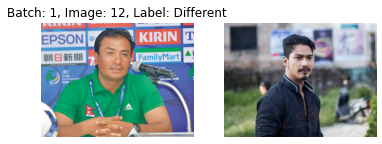

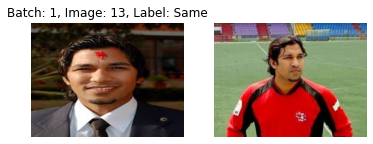

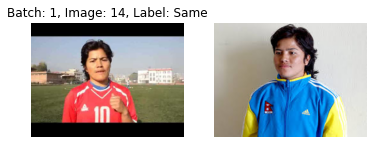

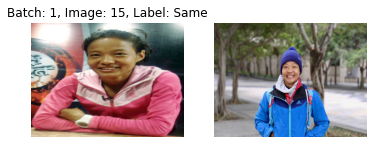

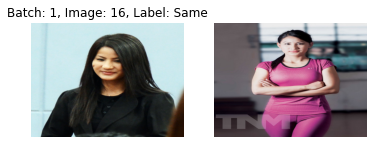

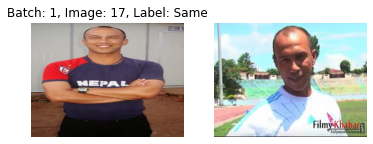

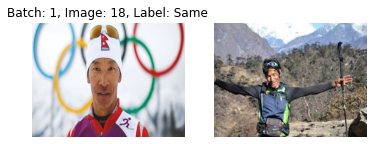

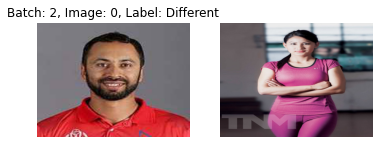

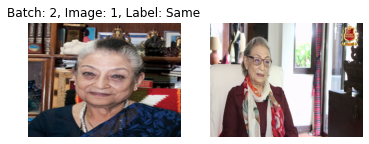

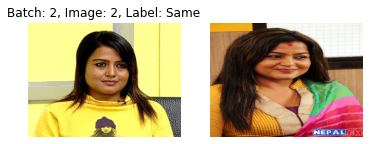

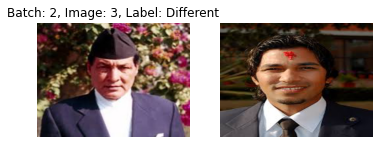

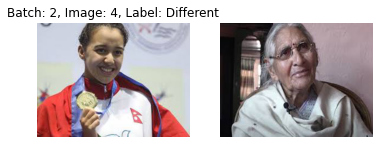

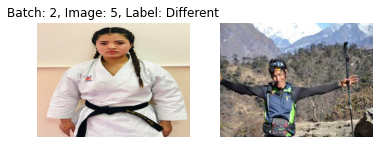

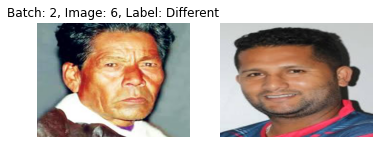

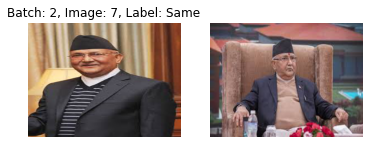

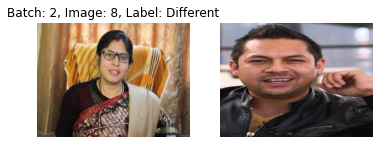

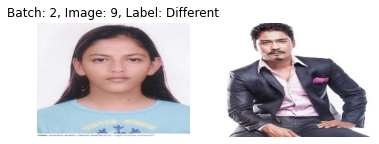

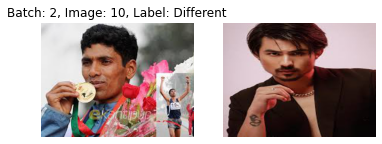

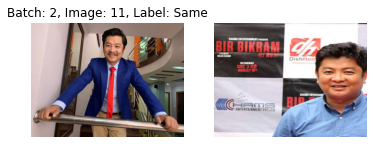

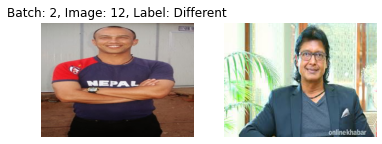

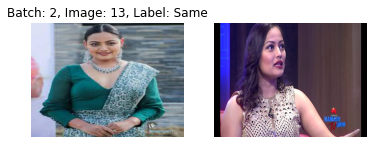

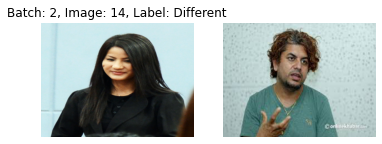

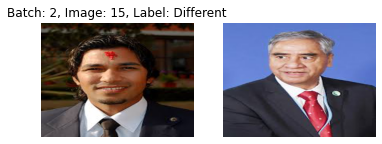

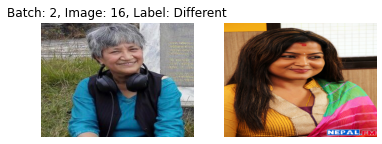

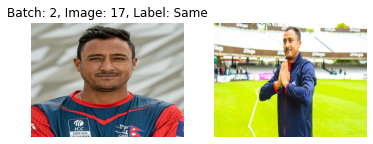

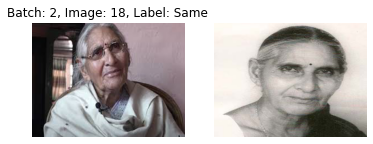

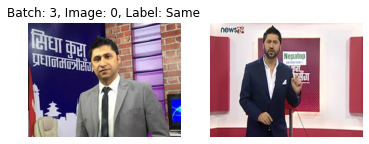

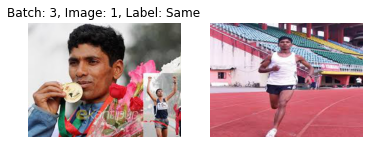

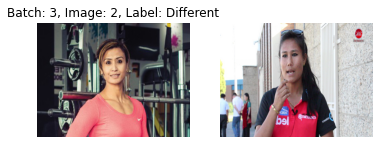

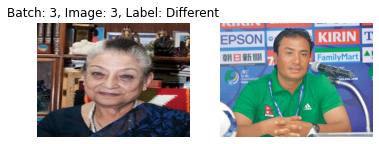

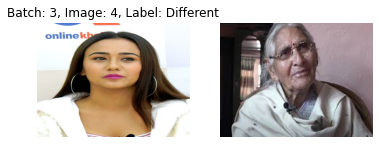

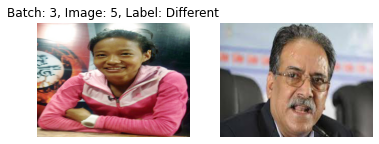

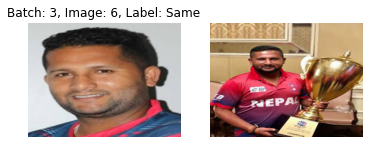

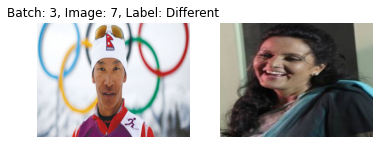

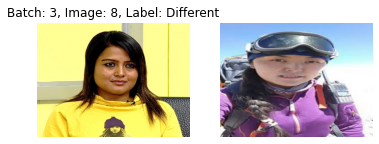

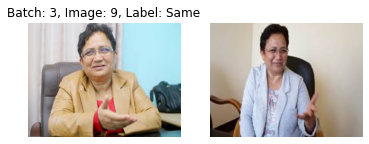

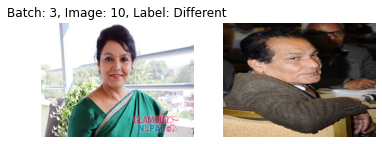

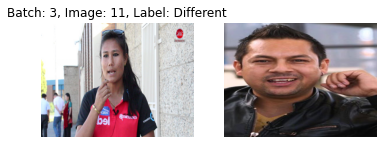

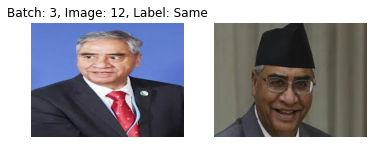

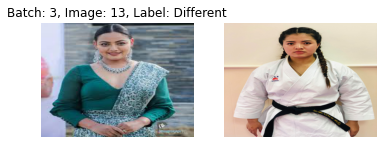

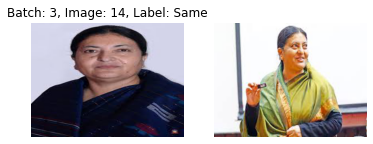

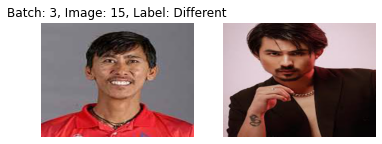

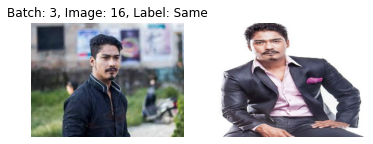

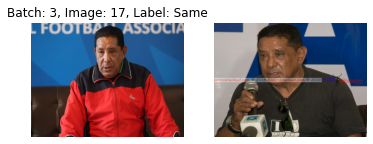

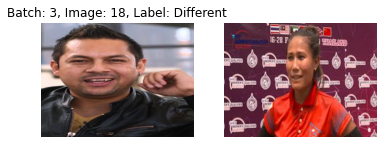

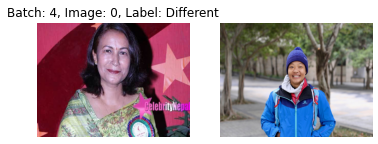

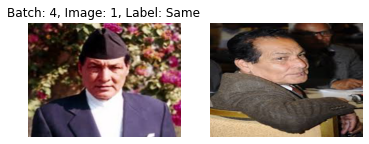

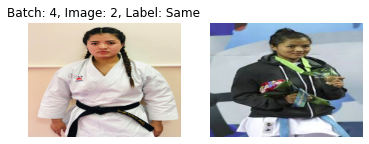

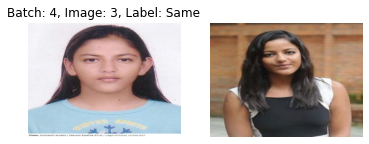

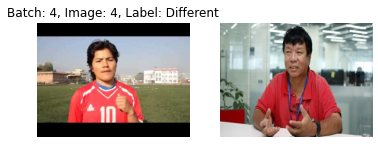

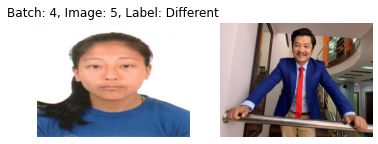

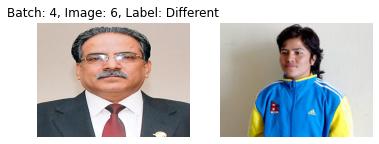

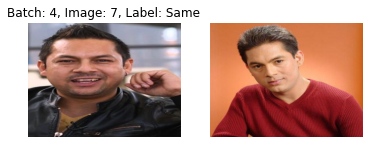

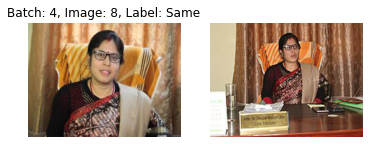

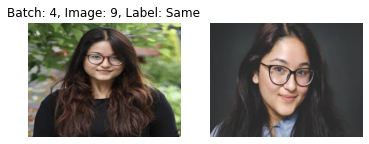

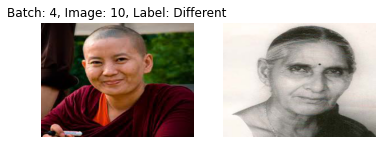

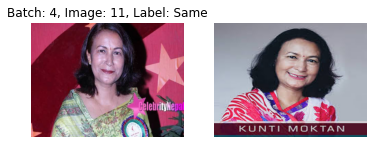

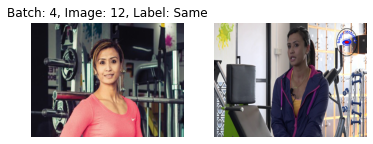

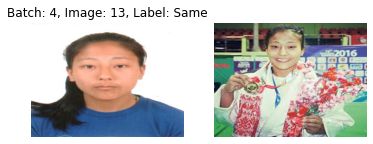

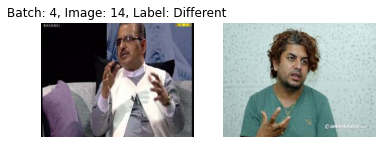

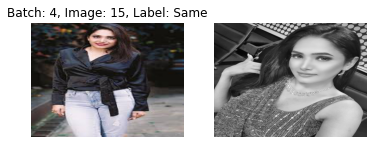

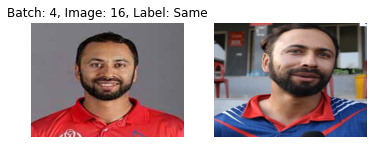

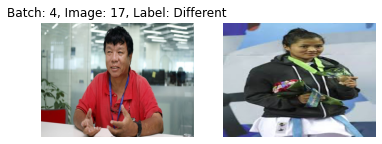

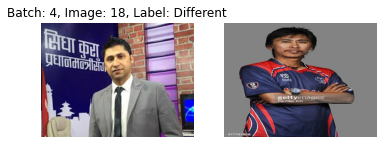

In [14]:
cropped_faces_1 = []
cropped_faces_2 = []
results = []

for batch_idx, (batch_data, batch_targets) in enumerate(pairs_loader):
    cropped_faces_1.append(mtcnn(batch_data[:, 0].cpu()))
    cropped_faces_2.append(mtcnn(batch_data[:, 1].cpu()))
    results.extend(batch_targets)
    
    for img_idx, (data, target) in enumerate(
        zip(batch_data, batch_targets)):
        
        fig, axes = plt.subplots(1, 2)
        axes[0].set_title(
            f"Batch: {batch_idx}, Image: {img_idx}, Label: " +
            ("Same" if target.item() == 0 else "Different"))
        axes[0].imshow(data[0].cpu())
        axes[0].axis("off")
        axes[1].imshow(data[1].cpu())
        axes[1].axis("off")
        fig.show()

    plt.close()

In [15]:
final_faces_1 = torch.stack([face.cpu() if face is not None else
                             torch.zeros(
                                 (3, 160, 160), device=args["device"])
                             for faces in cropped_faces_1
                             for face in faces])

final_faces_2 = torch.stack([face.cpu() if face is not None else
                             torch.zeros(
                                 (3, 160, 160), device=args["device"])
                             for faces in cropped_faces_2
                             for face in faces])

print(len(final_faces_1), len(final_faces_2))
print(final_faces_1[0].shape, final_faces_2[0].shape)

100 100
torch.Size([3, 160, 160]) torch.Size([3, 160, 160])


In [16]:
# Calculate face embeddings using the pretrained InceptionResnetV1
# provided in pytorch.
resnet = InceptionResnetV1(
    pretrained="vggface2", classify=False).eval().to(device=args["device"])

In [17]:
embeddings_1 = resnet(final_faces_1).detach().cpu()
embeddings_2 = resnet(final_faces_2).detach().cpu()

In [18]:
embeddings_1.shape, embeddings_2.shape

(torch.Size([100, 512]), torch.Size([100, 512]))

In [19]:
import pandas as pd

# Calculate similarity scores
euc_dists = np.array([(e1 - e2).norm()
                      for e1, e2 in zip(embeddings_1, embeddings_2)])
cos_dists = np.array([torch.dot(e1, e2) / (e1.norm() * e2.norm())
                      for e1, e2 in zip(embeddings_1, embeddings_2)])

# Extract labels and calculate predictions
labels = np.array([r.item() for r in results], dtype="uint8")
predictions = np.array(cos_dists < 0.6, dtype="uint8")

# Calculate accuracy
accuracy = sum(labels == predictions) / len(labels) * 100

display(pd.DataFrame(euc_dists, columns=["Euc Dist"])[:10])
display(pd.DataFrame(cos_dists, columns=["Cos Sim"])[:10])
display(pd.DataFrame(labels, columns=["Label"])[:10])
display(pd.DataFrame(predictions, columns=["Prediction"])[:10])

print(f"Accuracy = {accuracy}%")

,Euc Dist
0,0.675545
1,1.155823
2,1.427874
3,1.356315
4,1.431023
5,0.675079
6,0.936351
7,1.264694
8,1.471587
9,1.266150


,Cos Sim
0,0.771820
1,0.332037
2,-0.019413
3,0.080205
4,-0.023914
5,0.772134
6,0.561624
7,0.200274
8,-0.082783
9,0.198432


,Label
0,0
1,1
2,1
3,1
4,1
5,0
6,0
7,1
8,1
9,1


,Prediction
0,0
1,1
2,1
3,1
4,1
5,0
6,1
7,1
8,1
9,1


Accuracy = 89.0%
